# Adjacent deadline lead/lag research

Does a liquid deadline contract move before related contracts, especially during unusual trading activity?

**Historical mode requires no session recording.** It downloads public price history and individual taker fills through Polytrader, caches them locally, and measures subsequent **price changes**. It does not estimate executable profit.

Three modes are available:
- `historical`: real prices and trades; price/volume research without quotes.
- `recording`: Polytrader best-quote JSONL; ask-to-bid markouts and quote activity.
- `synthetic`: offline plumbing check with deliberately planted lead/lag.

Historical price observations are not bids, asks, or guaranteed execution prices. Missing observations stay missing. Trade timestamps have second precision and do not establish exchange-level reaction order within a second.

In [36]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from polytrader.data import PolymarketClient, discover
from polytrader.research.lead_lag import load_historical_inputs, historical_panels

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "pyproject.toml").exists() and (p / "src/polytrader").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Run inside the Polytrader repository using its .venv kernel.")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

## 1. Select data and markets

Use the repository `.venv` kernel (`pip install -e ".[sandbox]"` from the repository root if needed).

The defaults use the requested Russia–Ukraine ceasefire event: **December 2026 YES as the candidate leader**, with November and October 2026 YES as followers. December had the highest reported lifetime volume of these three when configured; this is a starting hypothesis, not proof of leadership. November is adjacent to December; October provides a second, non-adjacent comparison. Inspect the returned recent-window volume and test the reverse direction too.

For other real markets:
1. Set `EVENT` to a top-level Polymarket event URL or slug and run the discovery cell below.
2. Copy the chosen YES tokens into `LEADER_TOKEN` and `FOLLOWER_TOKENS`. Select comparable event definitions and adjacent deadlines yourself; discovery does not certify comparability. The leader need not be the earliest deadline.
3. Run the notebook again. Alternatively supply `TOKEN_CONDITIONS` directly, including every selected token; no event discovery or seven-contract audit is required.

`END_UTC=None` freezes the end on the **first download** in `CACHE_DIR`. Reruns reuse that window and downloaded pages. For a newer snapshot choose a new cache directory or set an explicit later end. A completed older cache is not automatically refreshed. Only run one downloader against a given cache directory at a time.

Start with a recent seven-day window at one-minute resolution. Older history may require five-minute or coarser buckets. Actual returned resolution and observed coverage are checked; a finer grid does not manufacture finer data. Network requests run only in historical mode (plus optional event discovery).

In [51]:
DATA_MODE = "historical"  # "historical", "recording", or "synthetic"
EVENT = "https://polymarket.com/event/russia-x-ukraine-ceasefire-agreement-by"
LEADER_TOKEN = "99878393523957043401217108863095556720659532630565063651671026144852955005052"  # December 2026 YES
FOLLOWER_TOKENS = [
    "92891603310020284971853769274013951144660180302451630607247552989141667117598",  # November 2026 YES
    "10861802947610899379330568332287100318869035186187733531205554992019689450318",  # October 2026 YES
]
# Optional direct token -> condition mapping; discovery fills this when EVENT is set.
TOKEN_CONDITIONS = {}
TOKEN_LABELS = {
    LEADER_TOKEN: "December 2026 YES",
    FOLLOWER_TOKENS[0]: "November 2026 YES",
    FOLLOWER_TOKENS[1]: "October 2026 YES",
}

HISTORY_DAYS = 7
END_UTC = None  # e.g. "2026-10-04T00:00:00Z"; None reuses the cached end
HISTORY_BUCKET_SECONDS = 60
CACHE_DIR = ROOT / "data/research/lead_lag/russia_ukraine_2026"
TRADE_MAX_PAGES = 20000  # hitting this is an error, never a silently truncated sample

RECORDING_PATH = ROOT / "data/orderbooks/session.jsonl"
GRID = f"{HISTORY_BUCKET_SECONDS}s" if DATA_MODE == "historical" else "5s"
LOOKBACK_SECONDS = [60, 300, 900] if DATA_MODE == "historical" else [30, 60, 300]
HORIZON_SECONDS = [300, 900, 1800] if DATA_MODE == "historical" else [30, 60, 300, 900]
PRIMARY_LOOKBACK = 60
MIN_LEADER_MOVE_PP = 0.50
SIGNAL_COOLDOWN_S = 60
TRAIN_FRAC = 0.70
ROLLING_BASELINE = "30min"
MIN_BASELINE_OBS = 20
RANDOM_SEED = 7
assert DATA_MODE in {"historical", "recording", "synthetic"}

In [52]:
if DATA_MODE == "historical" and EVENT:
    event, markets = discover(PolymarketClient(), EVENT)
    market_rows = []
    for market in markets:
        for outcome, token in market.tokens.items():
            condition = market.raw.get("conditionId")
            market_rows.append({"question": market.question, "outcome": outcome,
                                "token_id": token, "condition_id": condition,
                                "market_slug": market.slug})
            if condition:
                TOKEN_CONDITIONS.setdefault(token, condition)
            TOKEN_LABELS.setdefault(token, f"{market.question} / {outcome}")
    display(pd.DataFrame(market_rows))
elif DATA_MODE == "historical":
    print("Set EVENT above to discover tokens, or provide TOKEN_CONDITIONS directly.")

,question,outcome,token_id,condition_id,market_slug
0,Russia x Ukraine ceasefire agreement by May 31...,Yes,1835885860513181947531126082364810136330753346...,0x8fc1879ce3145520c750a9f4003f6534ada080acb101...,russia-x-ukraine-ceasefire-agreement-by-may-31...
1,Russia x Ukraine ceasefire agreement by May 31...,No,8196325214131437272082142336959872201766089772...,0x8fc1879ce3145520c750a9f4003f6534ada080acb101...,russia-x-ukraine-ceasefire-agreement-by-may-31...
2,Russia x Ukraine ceasefire agreement by June 3...,Yes,1042941188858490193528324149502317636333964105...,0x60c6fe27d5b273f54fe30b4003c3b2553acd5f76220d...,russia-x-ukraine-ceasefire-agreement-by-june-3...
3,Russia x Ukraine ceasefire agreement by June 3...,No,9623991196620391498821707352097007689213973965...,0x60c6fe27d5b273f54fe30b4003c3b2553acd5f76220d...,russia-x-ukraine-ceasefire-agreement-by-june-3...
4,Russia x Ukraine ceasefire agreement by Octobe...,Yes,1086180294761089937933056833228710031886903518...,0x6c3f1009a0c91ba9f7aae44aeadf86863b0d433b60f7...,russia-x-ukraine-ceasefire-agreement-by-octobe...
5,Russia x Ukraine ceasefire agreement by Octobe...,No,3931976964813241447617010373990077063300901250...,0x6c3f1009a0c91ba9f7aae44aeadf86863b0d433b60f7...,russia-x-ukraine-ceasefire-agreement-by-octobe...
6,Russia x Ukraine ceasefire agreement by Decemb...,Yes,9987839352395704340121710886309555672065953263...,0x5c19f205507ce03ff5f3be08a8090a5969ea6870cc07...,russia-x-ukraine-ceasefire-agreement-by-decemb...
7,Russia x Ukraine ceasefire agreement by Decemb...,No,6956528441108970827112869279074515209012906652...,0x5c19f205507ce03ff5f3be08a8090a5969ea6870cc07...,russia-x-ukraine-ceasefire-agreement-by-decemb...
8,Russia x Ukraine ceasefire agreement by August...,Yes,2678094617319061514503388728569878198375615766...,0xfb8ac17fdf80c31eb666086c6d278a076774d527faba...,russia-x-ukraine-ceasefire-agreement-by-august...
9,Russia x Ukraine ceasefire agreement by August...,No,2712446836835549721864227761517871508501680442...,0xfb8ac17fdf80c31eb666086c6d278a076774d527faba...,russia-x-ukraine-ceasefire-agreement-by-august...


## 2. Load inputs

The v2 trade feed is paginated by cursor. Date filtering is local because market feeds ignore start/end bounds. The downloader preserves identical fills and filters to the selected outcome tokens. Cached files contain analysis fields only, not wallet profiles.

An empty or incomplete response is not evidence that a market had no activity. Page-limit and pagination errors stop the analysis. Volume bars later mean **returned fills**, not independently verified total exchange activity.

Sources: [trade API](https://docs.polymarket.com/api-reference/feeds/list-trades), [price history](https://docs.polymarket.com/api-reference/markets/get-a-tokens-price-history).

In [53]:
def _to_float(x):
    if x is None:
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

def _first_attr(obj, names, default=None):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)
    return default

def _level_price_and_size(level, quote, side):
    if level is None:
        price = np.nan
        size = np.nan
    elif hasattr(level, "price"):
        price = _to_float(getattr(level, "price", None))
        size = _to_float(getattr(level, "size", None))
    else:
        price = _to_float(level)
        size = np.nan

    if np.isnan(size):
        size_names = (
            ["best_bid_size", "bid_size", "best_bid_quantity", "bid_quantity"]
            if side == "bid"
            else ["best_ask_size", "ask_size", "best_ask_quantity", "ask_quantity"]
        )
        size = _to_float(_first_attr(quote, size_names))
    return price, size

def load_polytrader_recording(path):
    from polytrader.orderbook import load_recording

    recording = load_recording(path)
    rows = []

    for frame in recording.frames():
        ts = pd.Timestamp(frame.recorded_at)
        if ts.tzinfo is None:
            ts = ts.tz_localize("UTC")
        else:
            ts = ts.tz_convert("UTC")

        for token_id, quote in frame.quotes.items():
            bid_obj = _first_attr(quote, ["best_bid", "bid"])
            ask_obj = _first_attr(quote, ["best_ask", "ask"])
            bid, bid_size = _level_price_and_size(bid_obj, quote, "bid")
            ask, ask_size = _level_price_and_size(ask_obj, quote, "ask")

            status = _first_attr(quote, ["status"], None)
            source_updated_at = _first_attr(quote, ["updated_at", "source_updated_at"], None)
            if source_updated_at is not None:
                try:
                    source_updated_at = pd.Timestamp(source_updated_at)
                    if source_updated_at.tzinfo is None:
                        source_updated_at = source_updated_at.tz_localize("UTC")
                    else:
                        source_updated_at = source_updated_at.tz_convert("UTC")
                except Exception:
                    source_updated_at = pd.NaT

            rows.append({
                "timestamp": ts,
                "token_id": str(token_id),
                "bid": bid,
                "ask": ask,
                "bid_size": bid_size,
                "ask_size": ask_size,
                "status": status,
                "source_updated_at": source_updated_at,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("Recording contained no reconstructed quote rows.")

    df = df.sort_values(["token_id", "timestamp"]).reset_index(drop=True)
    df["midpoint"] = (df["bid"] + df["ask"]) / 2.0
    df["spread"] = df["ask"] - df["bid"]
    df["top_depth"] = df["bid_size"].fillna(0) + df["ask_size"].fillna(0)
    denom = df["top_depth"].replace(0, np.nan)
    df["book_imbalance"] = (df["bid_size"].fillna(0) - df["ask_size"].fillna(0)) / denom
    return df

def make_synthetic_data(seed=7, periods=7_200, freq="5s"):
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2026-09-01", periods=periods, freq=freq, tz="UTC")

    leader = 0.42 + np.cumsum(rng.normal(0, 0.00035, periods))
    leader = np.clip(leader, 0.08, 0.90)

    # Sparse information impulses. Some are volume-confirmed, others are not.
    impulse = np.zeros(periods)
    impulse_locs = rng.choice(np.arange(100, periods - 100), size=65, replace=False)
    impulse_sizes = rng.choice([0.005, 0.008, 0.012, 0.018], size=len(impulse_locs), p=[0.30, 0.35, 0.25, 0.10])
    confirmed = rng.random(len(impulse_locs)) < 0.55
    impulse[impulse_locs] = impulse_sizes
    leader = np.clip(leader + np.cumsum(impulse), 0.08, 0.92)

    # Followers inherit the leader with delayed catch-up. Volume-confirmed leader moves
    # create much stronger follower reactions than unconfirmed moves.
    follower1 = 0.54 + np.cumsum(rng.normal(0, 0.00020, periods))
    follower2 = 0.64 + np.cumsum(rng.normal(0, 0.00016, periods))

    for t, s, is_confirmed in zip(impulse_locs, impulse_sizes, confirmed):
        lag1 = rng.integers(4, 13)   # 20-60s
        lag2 = rng.integers(9, 31)   # 45-150s
        strength1 = rng.uniform(0.70, 1.00) if is_confirmed else rng.uniform(0.10, 0.35)
        strength2 = rng.uniform(0.50, 0.85) if is_confirmed else rng.uniform(0.05, 0.25)
        if t + lag1 < periods:
            follower1[t + lag1:] += s * strength1
        if t + lag2 < periods:
            follower2[t + lag2:] += s * strength2

    follower1 = np.clip(follower1, 0.10, 0.95)
    follower2 = np.clip(follower2, 0.10, 0.97)

    tokens = {
        "LEADER": (leader, 0.004),
        "FOLLOWER_1": (follower1, 0.008),
        "FOLLOWER_2": (follower2, 0.012),
    }

    rows = []
    for token, (mid, spread) in tokens.items():
        bid = np.clip(mid - spread / 2, 0.001, 0.999)
        ask = np.clip(mid + spread / 2, 0.001, 0.999)
        depth_scale = 900 if token == "LEADER" else 220
        bid_size = rng.lognormal(np.log(depth_scale), 0.45, periods)
        ask_size = rng.lognormal(np.log(depth_scale), 0.45, periods)

        change_prob = 0.75 if token == "LEADER" else 0.25
        changed = rng.random(periods) < change_prob

        for i, ts in enumerate(idx):
            rows.append({
                "timestamp": ts,
                "token_id": token,
                "bid": bid[i],
                "ask": ask[i],
                "bid_size": bid_size[i],
                "ask_size": ask_size[i],
                "midpoint": mid[i],
                "spread": ask[i] - bid[i],
                "top_depth": bid_size[i] + ask_size[i],
                "book_imbalance": (bid_size[i] - ask_size[i]) / (bid_size[i] + ask_size[i]),
                "status": "live",
                "source_updated_at": ts if changed[i] else pd.NaT,
                "quote_changed_raw": int(changed[i]),
            })

    quotes = pd.DataFrame(rows)

    # Synthetic trade tape. Confirmed impulses have much larger, buy-heavy bursts.
    confirmed_by_loc = {int(t): bool(c) for t, c in zip(impulse_locs, confirmed)}
    trade_rows = []
    for i, ts in enumerate(idx):
        base_n = rng.poisson(2.5)
        if i in confirmed_by_loc and confirmed_by_loc[i]:
            extra = 28
            buy_prob = 0.84
        elif i in confirmed_by_loc:
            extra = 2
            buy_prob = 0.58
        else:
            extra = 0
            buy_prob = 0.50

        for _ in range(base_n + extra):
            size = float(rng.lognormal(3.2 if extra >= 20 else 2.4, 0.7))
            side = "BUY" if rng.random() < buy_prob else "SELL"
            trade_rows.append({
                "timestamp": ts,
                "token_id": "LEADER",
                "price": float(leader[i]),
                "size": size,
                "side": side,
                "notional_usdc": float(leader[i]) * size,
            })

    trades = pd.DataFrame(trade_rows)
    return quotes, trades

In [54]:
HAS_QUOTES = DATA_MODE != "historical"
if DATA_MODE == "synthetic":
    quotes, trades = make_synthetic_data(RANDOM_SEED)
    LEADER_TOKEN, FOLLOWER_TOKENS = "LEADER", ["FOLLOWER_1", "FOLLOWER_2"]
    TOKEN_LABELS.update({"LEADER": "Synthetic leader", "FOLLOWER_1": "Synthetic follower 1",
                         "FOLLOWER_2": "Synthetic follower 2"})
elif DATA_MODE == "recording":
    quotes = load_polytrader_recording(RECORDING_PATH)
    display(quotes.groupby("token_id").agg(observations=("timestamp", "size"),
                median_spread=("spread", "median"), median_depth=("top_depth", "median")))
    trades = pd.DataFrame()

if LEADER_TOKEN is None or not FOLLOWER_TOKENS:
    raise ValueError("Select LEADER_TOKEN and FOLLOWER_TOKENS in configuration using the table above, then rerun.")
LEADER_TOKEN = str(LEADER_TOKEN)
FOLLOWER_TOKENS = list(map(str, FOLLOWER_TOKENS))
TOKENS = [LEADER_TOKEN] + FOLLOWER_TOKENS
if len(TOKENS) != len(set(TOKENS)):
    raise ValueError("Leader and followers must be distinct tokens.")

if DATA_MODE == "historical":
    missing = set(TOKENS) - set(TOKEN_CONDITIONS)
    if missing:
        raise ValueError(f"Missing condition IDs for {missing}. Set EVENT or TOKEN_CONDITIONS.")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    window_path = CACHE_DIR / "window.json"
    if END_UTC is None and window_path.exists():
        frozen_end = pd.Timestamp(json.loads(window_path.read_text())["end_utc"])
    else:
        frozen_end = pd.Timestamp.now(tz="UTC").floor("s") if END_UTC is None else pd.Timestamp(END_UTC)
    if frozen_end.tzinfo is None:
        raise ValueError("END_UTC must include a timezone.")
    frozen_end = frozen_end.tz_convert("UTC").floor("s")
    if frozen_end > pd.Timestamp.now(tz="UTC") or HISTORY_DAYS <= 0:
        raise ValueError("Choose a past end and positive HISTORY_DAYS.")
    if not window_path.exists() and END_UTC is None:
        window_path.write_text(json.dumps({"end_utc": frozen_end.isoformat()}))
    start = frozen_end - pd.Timedelta(days=HISTORY_DAYS)
    print("Requested window:", start, "to", frozen_end, "(exclusive)")
    prices, trades = load_historical_inputs(
        {t: TOKEN_CONDITIONS[t] for t in TOKENS}, int(start.timestamp()), int(frozen_end.timestamp()),
        bucket_seconds=HISTORY_BUCKET_SECONDS, cache_dir=CACHE_DIR, max_pages=TRADE_MAX_PAGES)
    display(prices.groupby("token_id").agg(first=("timestamp", "min"), last=("timestamp", "max"),
             observations=("price", "count"), actual_resolution_s=("resolution_seconds", "max")))

print("Returned trade fills:", len(trades))
if not trades.empty:
    display(trades.groupby("token_id").agg(first=("timestamp", "min"), last=("timestamp", "max"),
             fills=("size", "size"), shares=("size", "sum"), notional=("notional_usdc", "sum")))

Requested window: 2026-09-27 18:10:03+00:00 to 2026-10-04 18:10:03+00:00 (exclusive)
Prices: 99878393523957043401217108863095556720659532630565063651671026144852955005052
Prices: 92891603310020284971853769274013951144660180302451630607247552989141667117598
Prices: 10861802947610899379330568332287100318869035186187733531205554992019689450318
Trades: 0x5c19f205507ce03ff5f3be08a8090a5969ea6870cc07b902a4ca2e61dfe48fdd (cached pages resume automatically)
Trades: 0x346543618b5077cedcabb9da57cf643922dbc752a7f332fc26e0256a38bb74c7 (cached pages resume automatically)
Trades: 0x6c3f1009a0c91ba9f7aae44aeadf86863b0d433b60f7a090fd00c945019aa32f (cached pages resume automatically)


,first,last,observations,actual_resolution_s
token_id,,,,
10861802947610899379330568332287100318869035186187733531205554992019689450318,2026-09-27 18:11:00+00:00,2026-10-04 17:58:00+00:00,10068,60
92891603310020284971853769274013951144660180302451630607247552989141667117598,2026-09-27 18:11:00+00:00,2026-10-04 17:58:00+00:00,10062,60
99878393523957043401217108863095556720659532630565063651671026144852955005052,2026-09-27 18:11:00+00:00,2026-10-04 17:58:00+00:00,10066,60


Returned trade fills: 182


,first,last,fills,shares,notional
token_id,,,,,
10861802947610899379330568332287100318869035186187733531205554992019689450318,2026-09-27 18:14:36+00:00,2026-10-04 17:48:37+00:00,77,66131.487461,3450.436481
92891603310020284971853769274013951144660180302451630607247552989141667117598,2026-09-27 18:41:30+00:00,2026-10-04 17:29:29+00:00,18,10601.022712,949.265100
99878393523957043401217108863095556720659532630565063651671026144852955005052,2026-09-27 19:13:03+00:00,2026-10-04 08:15:01+00:00,87,24070.713251,4131.247000


## 3. Build causal panels and features

Historical mode uses exact grid-aligned price observations and leaves missing prices missing. Off-grid terminal observations are not shifted backwards into a decision time. Trade bars use `[t-grid, t)` and are labelled at **t**; trades at t enter the next bar. Volume z-scores compare with a baseline ending before the current activity window.

Recording mode reconstructs the last known state at or before each decision time, including missing sides and feed statuses. Only `live` quotes enter targets. Quote-change activity is a sampled proxy, not traded volume. Quiet quotes on a healthy live feed remain usable.

In [41]:
def rows_for(seconds):
    step = pd.Timedelta(GRID).total_seconds()
    if seconds < 0 or seconds % step:
        raise ValueError(f"{seconds}s must be a nonnegative multiple of GRID={GRID}")
    return int(seconds / step)

for duration in LOOKBACK_SECONDS + HORIZON_SECONDS:
    if rows_for(duration) < 1:
        raise ValueError("Lookbacks and horizons must be at least one grid step.")
if PRIMARY_LOOKBACK not in LOOKBACK_SECONDS:
    raise ValueError("PRIMARY_LOOKBACK must be in LOOKBACK_SECONDS")

def quote_panels_from_recording(quotes):
    index = pd.date_range(quotes.timestamp.min().ceil(GRID), quotes.timestamp.max().floor(GRID),
                          freq=GRID, tz="UTC")
    panels = {}
    for token in TOKENS:
        g = quotes[quotes.token_id.eq(token)].sort_values("timestamp").drop_duplicates("timestamp", keep="last").copy()
        if g.empty:
            raise ValueError(f"No quotes for selected token {token}")
        fields = ["bid", "ask", "bid_size", "ask_size"]
        changed = g[fields].ne(g[fields].shift()).any(axis=1)
        g["last_change"] = g.timestamp.where(changed).ffill()
        g["quote_changes"] = changed.astype(int)
        state = pd.merge_asof(pd.DataFrame({"timestamp": index}), g, on="timestamp", direction="backward").set_index("timestamp")
        valid = state.status.eq("live") & state.bid.notna() & state.ask.notna() & state.ask.ge(state.bid)
        state["price"] = state.midpoint.where(valid)
        state["bid"] = state.bid.where(valid)
        state["ask"] = state.ask.where(valid)
        state["quote_age_s"] = (state.index.to_series() - state.last_change).dt.total_seconds()
        state["quote_changes"] = g.set_index("timestamp").quote_changes.resample(
            GRID, closed="left", label="right").sum().reindex(index, fill_value=0)
        panels[token] = state
    return panels

panels = historical_panels(prices, TOKENS, GRID) if not HAS_QUOTES else quote_panels_from_recording(quotes)
baseline_rows = int(pd.Timedelta(ROLLING_BASELINE) / pd.Timedelta(GRID))
if baseline_rows < MIN_BASELINE_OBS:
    raise ValueError("ROLLING_BASELINE is shorter than MIN_BASELINE_OBS; increase baseline or reduce minimum.")

for token, p in panels.items():
    tape = trades[trades.token_id.eq(token)].copy() if not trades.empty else pd.DataFrame()
    if DATA_MODE == "historical" and tape.empty:
        raise ValueError(f"No returned trades for {token}; do not treat an unserved feed as zero activity.")
    if not tape.empty:
        tape["signed_volume"] = np.where(tape.side.eq("BUY"), tape["size"], -tape["size"])
        bars = tape.set_index("timestamp").resample(GRID, closed="left", label="right").agg(
            volume=("size", "sum"), notional=("notional_usdc", "sum"),
            count=("size", "size"), signed_volume=("signed_volume", "sum"))
        for col in bars:
            p[col] = bars[col].reindex(p.index, fill_value=0)
        if DATA_MODE == "historical":
            # A first bar that starts before the requested download window is incomplete.
            p.loc[p.index - pd.Timedelta(GRID) < start, list(bars.columns)] = np.nan
        p["activity"] = p.volume
        p["activity_source"] = "returned trade share volume"
    else:
        p["activity"] = p.quote_changes
        p["activity_source"] = "sampled quote changes"
    for sec in LOOKBACK_SECONDS:
        count = rows_for(sec)
        p[f"move_{sec}"] = 100 * p.price.diff(count)
        current = p.activity.rolling(count, min_periods=count).sum()
        # Exclude every bar in the current activity window from its baseline.
        past = current.shift(count)
        mean = past.rolling(baseline_rows, min_periods=MIN_BASELINE_OBS).mean()
        std = past.rolling(baseline_rows, min_periods=MIN_BASELINE_OBS).std()
        p[f"activity_z_{sec}"] = (current - mean) / std.replace(0, np.nan)

display(pd.DataFrame([{"token": TOKEN_LABELS.get(t, t), "grid_rows": len(p),
    "observed_prices": p.price.notna().sum(), "missing_price_fraction": p.price.isna().mean(),
    "activity": p.activity_source.iloc[0]} for t, p in panels.items()]))

,token,grid_rows,observed_prices,missing_price_fraction,activity
0,December 2026 YES,10068,10066,0.000199,returned trade share volume
1,November 2026 YES,10068,10062,0.000596,returned trade share volume
2,October 2026 YES,10068,10068,0.000000,returned trade share volume


## 4. Leader → follower outcomes

Historical target: `100 × (future observed price − current observed price)` in percentage points. This is price follow-through, **not P&L**. Recording/synthetic target: `100 × (future bid − current ask)`, before fees, slippage, latency and size constraints.

Targets require valid endpoints and remain missing when future observations are missing. Follower quote age, spreads and depth are used only when actual quotes are available. Historical mode does not substitute price-observation age for quote staleness.

In [42]:
TARGET_LABEL = "Ask-to-bid markout (pp), before other costs" if HAS_QUOTES else "Observed price change (pp), not profit"
pairs = {}
for follower in FOLLOWER_TOKENS:
    pair = panels[LEADER_TOKEN].add_prefix("L_").join(panels[follower].add_prefix("F_"))
    pair["move"] = pair[f"L_move_{PRIMARY_LOOKBACK}"]
    pair["activity_z"] = pair[f"L_activity_z_{PRIMARY_LOOKBACK}"]
    pair["interaction"] = pair.move * pair.activity_z
    if HAS_QUOTES:
        pair["stale_gap_s"] = pair.F_quote_age_s - pair.L_quote_age_s
        pair["spread_ratio"] = pair.F_spread / pair.L_spread.replace(0, np.nan)
        pair["depth_ratio"] = pair.L_top_depth / pair.F_top_depth.replace(0, np.nan)
    for h in HORIZON_SECONDS:
        n = rows_for(h)
        pair[f"price_move_{h}"] = 100 * (pair.F_price.shift(-n) - pair.F_price)
        target = 100 * (pair.F_bid.shift(-n) - pair.F_ask) if HAS_QUOTES else pair[f"price_move_{h}"]
        # Both current contracts must be observable at the signal time.
        pair[f"target_{h}"] = target.where(pair.L_price.notna() & pair.F_price.notna())
    pairs[follower] = pair
print(TARGET_LABEL)
display(next(iter(pairs.values()))[["move", "activity_z"] + [f"target_{h}" for h in HORIZON_SECONDS]].tail())

Observed price change (pp), not profit


,move,activity_z,target_300,target_900,target_1800
2026-10-04 17:54:00+00:00,0.0,NaN,NaN,NaN,NaN
2026-10-04 17:55:00+00:00,0.0,NaN,NaN,NaN,NaN
2026-10-04 17:56:00+00:00,0.0,NaN,NaN,NaN,NaN
2026-10-04 17:57:00+00:00,0.0,NaN,NaN,NaN,NaN
2026-10-04 17:58:00+00:00,0.0,NaN,NaN,NaN,NaN


## 5. Lead/lag diagnostic

Positive lag means the follower moves after the leader. Negative lags are included as a directional comparison. Correlations use only observed paired returns; they do not establish a causal or executable trading advantage.

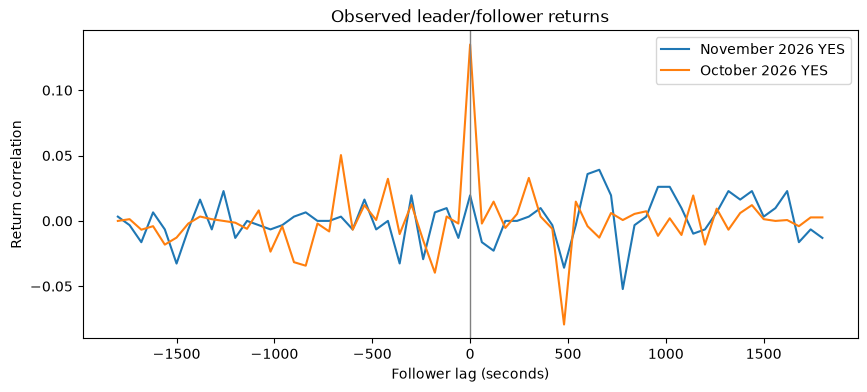

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
step = int(pd.Timedelta(GRID).total_seconds())
for follower, pair in pairs.items():
    lags = range(-max(HORIZON_SECONDS), max(HORIZON_SECONDS) + step, step)
    values = [pair.L_price.diff().corr(pair.F_price.diff().shift(-int(lag / step))) for lag in lags]
    ax.plot(list(lags), values, label=TOKEN_LABELS.get(follower, follower))
ax.axvline(0, color="gray", linewidth=1)
ax.set(xlabel="Follower lag (seconds)", ylabel="Return correlation", title="Observed leader/follower returns")
ax.legend()
plt.show()

## 6. Volume/activity confirmation and interaction

Exploratory full-sample summaries compare leader impulses across activity buckets and positive move × positive activity scores. These are descriptive, not holdout evidence. For each horizon we space selected events by at least that horizon, avoiding overlapping target windows within a follower/horizon. Different horizons and followers can still share events.

In historical mode, low-volume outcomes may have insufficient observed price coverage. Check counts and missing-price fractions before interpreting an apparent lead/lag.

In [44]:
def select_events(df, condition, cooldown_s):
    candidates = df.loc[condition.fillna(False)]
    keep, last = [], None
    for ts in candidates.index:
        if last is None or (ts - last).total_seconds() >= cooldown_s:
            keep.append(ts)
            last = ts
    return candidates.loc[keep]

def summarize(frame, target):
    y = frame[target].dropna()
    return {"n": len(y), "mean_pp": y.mean(), "median_pp": y.median(),
            "positive_fraction": (y > 0).mean() if len(y) else np.nan}

activity_results, interaction_results = [], []
for follower, pair in pairs.items():
    for h in HORIZON_SECONDS:
        target = f"target_{h}"
        events = select_events(pair, (pair.move >= MIN_LEADER_MOVE_PP) & pair[target].notna(), max(h, SIGNAL_COOLDOWN_S)).copy()
        events["activity_bucket"] = pd.cut(events.activity_z, [-np.inf, 0, 1, 2, np.inf],
                labels=["<0", "0–1", "1–2", "≥2"], right=False)
        for bucket, group in events.groupby("activity_bucket", observed=True):
            activity_results.append({"follower": TOKEN_LABELS.get(follower, follower), "horizon_s": h,
                "activity_bucket": str(bucket), **summarize(group, target)})
        score = events.move.clip(lower=0) * events.activity_z.clip(lower=0)
        if score[score > 0].nunique() >= 4:
            events["score_bucket"] = pd.qcut(score.where(score > 0), 4, duplicates="drop")
            for bucket, group in events.groupby("score_bucket", observed=True):
                interaction_results.append({"follower": TOKEN_LABELS.get(follower, follower), "horizon_s": h,
                    "score_bucket": str(bucket), **summarize(group, target)})
activity_results = pd.DataFrame(activity_results)
interaction_results = pd.DataFrame(interaction_results)
print(TARGET_LABEL)
display(activity_results, interaction_results)

Observed price change (pp), not profit


,follower,horizon_s,activity_bucket,n,mean_pp,median_pp,positive_fraction
0,November 2026 YES,300,<0,7,0.000000,0.00,0.000000
1,November 2026 YES,300,0–1,1,0.000000,0.00,0.000000
2,November 2026 YES,300,≥2,1,-1.000000,-1.00,0.000000
3,November 2026 YES,900,<0,7,0.000000,0.00,0.000000
4,November 2026 YES,900,0–1,1,0.000000,0.00,0.000000
5,November 2026 YES,900,≥2,1,-0.500000,-0.50,0.000000
6,November 2026 YES,1800,<0,6,-0.083333,0.00,0.000000
7,November 2026 YES,1800,0–1,1,0.000000,0.00,0.000000
8,November 2026 YES,1800,≥2,1,-0.500000,-0.50,0.000000
9,October 2026 YES,300,<0,7,-0.057143,0.00,0.000000


""


## 7. Chronological threshold validation

Select thresholds on the first 70% of grid time and hold them fixed for the final 30%. Training events whose outcomes reach the test boundary are purged. Event spacing is at least the evaluated horizon. Threshold search requires at least ten training events; an empty result is a legitimate outcome, not a reason to relax the threshold automatically.

The objective is mean target × √event count. It is a heuristic, not statistical significance. Multiple followers/horizons still create selection risk. Historical rules use move and activity only; recording rules can also require a quote-age gap.

In [45]:
def split_pair(pair, horizon):
    cut = int(len(pair) * TRAIN_FRAC)
    if not 0 < cut < len(pair):
        raise ValueError("Not enough grid rows for a chronological split")
    boundary = pair.index[cut]
    train = pair.loc[pair.index + pd.Timedelta(seconds=horizon) < boundary]
    test = pair.loc[pair.index >= boundary]
    return train, test

def evaluate_rule(frame, h, min_move, min_activity, min_stale=None):
    condition = (frame.move >= min_move) & (frame.activity_z >= min_activity) & frame[f"target_{h}"].notna()
    if min_stale is not None:
        condition &= frame.stale_gap_s >= min_stale
    events = select_events(frame, condition, max(h, SIGNAL_COOLDOWN_S))
    stats = summarize(events, f"target_{h}")
    stats["score"] = stats["mean_pp"] * np.sqrt(stats["n"]) if stats["n"] else -np.inf
    return stats

rule_results = []
for follower, pair in pairs.items():
    for h in HORIZON_SECONDS:
        train, test = split_pair(pair, h)
        candidates = []
        for move in [0.25, 0.5, 1.0, 1.5]:
            for activity in [-0.5, 0, 1, 2]:
                for stale in ([None, 0, 30, 120] if HAS_QUOTES else [None]):
                    stats = evaluate_rule(train, h, move, activity, stale)
                    if stats["n"] >= 10:
                        candidates.append((stats["score"], move, activity, stale, stats))
        if candidates:
            _, move, activity, stale, train_stats = max(candidates, key=lambda row: row[0])
            test_stats = evaluate_rule(test, h, move, activity, stale)
            rule_results.append({"follower": TOKEN_LABELS.get(follower, follower), "horizon_s": h,
                "min_move_pp": move, "min_activity_z": activity, "min_quote_age_gap_s": stale,
                **{f"train_{k}": v for k, v in train_stats.items() if k != "score"},
                **{f"test_{k}": v for k, v in test_stats.items() if k != "score"}})
rule_results = pd.DataFrame(rule_results)
print(TARGET_LABEL)
display(rule_results)
if rule_results.empty:
    print("No rule met the minimum training sample requirement.")

Observed price change (pp), not profit


""


No rule met the minimum training sample requirement.


## 8. Small linear model

The model uses leader move, activity and their interaction. Quote modes additionally use spreads, depth, quote age and book imbalance. Train/test separation uses the same purged chronological boundary; normalization and the top-decile prediction threshold are learned from training data only. Evaluation observations are spaced by the horizon. Coefficients and correlations describe this sample, not a validated trading strategy.

In [46]:
model_summaries = []
features = ["move", "activity_z", "interaction"]
if HAS_QUOTES:
    features += ["F_spread", "spread_ratio", "depth_ratio", "stale_gap_s", "F_book_imbalance"]
for follower, pair in pairs.items():
    for h in HORIZON_SECONDS:
        target = f"target_{h}"
        train, test = split_pair(pair, h)
        def usable(frame):
            frame = frame[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()
            return select_events(frame, pd.Series(True, index=frame.index), max(h, SIGNAL_COOLDOWN_S))
        train, test = usable(train), usable(test)
        if len(train) < max(30, 3 * len(features)) or len(test) < 10:
            continue
        mean, std = train[features].mean(), train[features].std().replace(0, 1)
        def matrix(frame):
            return np.column_stack([np.ones(len(frame)), ((frame[features] - mean) / std).to_numpy()])
        coef, *_ = np.linalg.lstsq(matrix(train), train[target].to_numpy(), rcond=None)
        threshold = np.quantile(matrix(train) @ coef, 0.9)
        prediction = matrix(test) @ coef
        top = test.loc[prediction >= threshold]
        model_summaries.append({"follower": TOKEN_LABELS.get(follower, follower), "horizon_s": h,
            "n_train": len(train), "n_test": len(test),
            "prediction_correlation": pd.Series(prediction, index=test.index).corr(test[target]),
            **{f"above_train_p90_{k}": v for k, v in summarize(top, target).items()}})
model_summaries = pd.DataFrame(model_summaries)
print(TARGET_LABEL)
display(model_summaries)
if model_summaries.empty:
    print("Insufficient non-overlapping observed samples for the linear model.")

Observed price change (pp), not profit


,follower,horizon_s,n_train,n_test,prediction_correlation,above_train_p90_n,above_train_p90_mean_pp,above_train_p90_median_pp,above_train_p90_positive_fraction
0,November 2026 YES,300,301,85,0.001449,4,0.000000,0.0,0.000000
1,November 2026 YES,900,104,30,0.031994,3,0.000000,0.0,0.333333
2,November 2026 YES,1800,55,17,0.002897,3,-0.166667,0.0,0.000000
3,October 2026 YES,300,301,85,0.028684,4,0.000000,0.0,0.000000
4,October 2026 YES,900,104,30,0.093504,2,0.000000,0.0,0.000000
5,October 2026 YES,1800,55,17,-0.006239,2,-0.200000,-0.2,0.000000


## Interpretation and next steps

Historical mode can answer whether observed leader moves plus unusual returned volume predict follower price changes. It cannot determine whether an order would have filled, or whether movement covered the spread. No bid/ask, depth or quote-staleness data are synthesized.

Look for repeated effects across comparable markets and held-out time, sufficient non-overlapping observations, and coverage that does not preferentially exclude quiet followers. Missing prices, retention limits, rounded timestamps, changing liquidity and multiple threshold/horizon comparisons can all distort apparent lead/lag. A positive result motivates collecting quotes and testing execution; it does not establish arbitrage profit.

All downloads remain under the root `data/research/lead_lag/` cache. The notebook places no orders. Synthetic mode intentionally plants the relationship and is only a sanity check.